<center><a href="https://www.nvidia.com/dli"> <img src="https://www.nvidia.com/content/dam/en-zz/Solutions/deep-learning/deep-learning-education/deep-learning-education-deep-learning-institute-logo-407-udt.png" width="200" </a></center>

In [ ]:
# Installing necessary libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
import matplotlib.pyplot as plt

# Assessment

In this assessment, you will train a new model that is able to recognize fresh and rotten fruit. You will need to get the model to a validation accuracy of `92%` in order to pass the assessment, though we challenge you to do even better if you can. You will have the use the skills that you learned in the previous exercises. Specifically, we suggest using some combination of transfer learning, data augmentation, and fine tuning. Once you have trained the model to be at least 92% accurate on the validation dataset, save your model, and then assess its accuracy. Let's get started!

## The Dataset

In this exercise, you will train a model to recognize fresh and rotten fruits. The dataset comes from [Kaggle](https://www.kaggle.com/sriramr/fruits-fresh-and-rotten-for-classification), a great place to go if you're interested in starting a project after this class. The dataset structure is in the `data/fruits` folder. There are 6 categories of fruits: fresh apples, fresh oranges, fresh bananas, rotten apples, rotten oranges, and rotten bananas. This will mean that your model will require an output layer of 6 neurons to do the categorization successfully. You'll also need to compile the model with `categorical_crossentropy`, as we have more than two categories.

In [ ]:
# Define the path to the dataset
path_data = '../Data/fruits/'

## Load ImageNet Base Model

We encourage you to start with a model pretrained on ImageNet. Load the model with the correct weights, set an input shape, and choose to remove the last layers of the model. Remember that images have three dimensions: a height, and width, and a number of channels. Because these pictures are in color, there will be three channels for red, green, and blue. We've filled in the input shape for you. This cannot be changed or the assessment will fail. If you need a reference for setting up the pretrained model, please take a look at [notebook 05b] where we implemented transfer learning.

## Freeze Base Model

Next, we suggest freezing the base model, as done in [notebook 05b]. This is done so that all the learning from the ImageNet dataset does not get destroyed in the initial training.

In [ ]:
base_model = keras.applications.VGG16(
    weights='imagenet',          # Load pre-trained weights
    input_shape=(224, 224, 3),   # Size of the images we defined in datagen
    include_top=False            # Remove the original dense layers
)

# Not freezing the base model to not lose the knowledge from ImageNet
base_model.trainable = True


## Add Layers to Model

Now it's time to add layers to the pretrained model. [Notebook 05b] can be used as a guide. Pay close attention to the last dense layer and make sure it has the correct number of neurons to classify the different types of fruit.

In [ ]:
#Creating the architecture

# Create the input

inputs = keras.Input(shape=(224, 224, 3))

# Pass the input through the base model
x = base_model(inputs, training=False)

# Add pooling to transform the feature map into a vector
x = keras.layers.GlobalAveragePooling2D()(x)

# Add an extra dense layer
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x) # Dropout to avoid overfitting

# Output layer with 6 neurons (one for each fruit/state)
outputs = keras.layers.Dense(6, activation='softmax')(x)

# Combine everything into the final model
model = keras.Model(inputs, outputs)

# View the summary of the architecture
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 14,847,558 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

Now it's time to compile the model with loss and metrics options. Remember that we're training on a number of different categories, rather than a binary classification problem.

In [39]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Augment the Data

If you'd like, try to augment the data to improve the dataset. Feel free to look at [notebook 04a] and [notebook 05b] for augmentation examples. There is also documentation for the [Keras ImageDataGenerator class](https://keras.io/api/preprocessing/image/#imagedatagenerator-class). This step is optional, but it may be helpful to get to 92% accuracy.

In [ ]:
# Create the data generator for training with data augmentation
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Configuration for validation
datagen_valid = ImageDataGenerator(rescale=1./255)

## Load Dataset

Now it's time to load the train and validation datasets. Pick the right folders, as well as the right `target_size` of the images (it needs to match the height and width input of the model you've created). For a reference, check out [notebook 05b].

In [ ]:
# Training loader
train_it = datagen_train.flow_from_directory(
    path_data + 'train/',
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32
)

Found 1182 images belonging to 6 classes.


In [ ]:
# Validation loader
valid_it = datagen_valid.flow_from_directory(
    path_data + 'valid/',
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32
)

Found 329 images belonging to 6 classes.


## Train the Model

Time to train the model! Pass the `train` and `valid` iterators into the `fit` function, as well as setting the desired number of epochs.

In [44]:
history_fine = model.fit(
    train_it,
    validation_data=valid_it,
    steps_per_epoch=int(train_it.samples / train_it.batch_size),
    validation_steps=int(valid_it.samples / valid_it.batch_size),
    epochs=16,
    verbose=1
)

Epoch 1/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 335s 9s/step - accuracy: 0.2939 - loss: 1.6687 - val_accuracy: 0.6313 - val_loss: 1.0933
Epoch 2/16
 1/36 ━━━━━━━━━━━━━━━━━━━━ 4:57 9s/step - accuracy: 0.5000 - loss: 1.3875

c:\NVidia Test\.venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 454ms/step - accuracy: 0.5000 - loss: 1.3875 - val_accuracy: 0.5531 - val_loss: 1.1261
Epoch 3/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 310s 9s/step - accuracy: 0.5983 - loss: 1.0914 - val_accuracy: 0.8188 - val_loss: 0.6238
Epoch 4/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 435ms/step - accuracy: 0.6875 - loss: 0.8720 - val_accuracy: 0.7937 - val_loss: 0.6200
Epoch 5/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 304s 8s/step - accuracy: 0.7043 - loss: 0.8055 - val_accuracy: 0.8250 - val_loss: 0.4647
Epoch 6/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 442ms/step - accuracy: 0.8125 - loss: 0.5807 - val_accuracy: 0.7781 - val_loss: 0.5606
Epoch 7/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 304s 8s/step - accuracy: 0.7783 - loss: 0.6286 - val_accuracy: 0.9031 - val_loss: 0.2896
Epoch 8/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 445ms/step - accuracy: 0.7812 - loss: 0.4929 - val_accuracy: 0.9156 - val_loss: 0.2874
Epoch 9/16
36/36 ━━━━━━━━━━━━━━━━━━━━ 303s 8s/step - accuracy: 0.8217 - loss: 0.5132 - val_accuracy: 0.9406 - val_

## Evaluate the Model

Hopefully, you now have a model that has a validation accuracy of 92% or higher. If not, you may want to go back and either run more epochs of training, or adjust your data augmentation.

Once you are satisfied with the validation accuracy, evaluate the model by executing the following cell. The evaluate function will return a tuple, where the first value is your loss, and the second value is your accuracy. To pass, the model will need have an accuracy value of `92% or higher`.

In [45]:
model.evaluate(valid_it, steps=int(valid_it.samples/valid_it.batch_size))

10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9375 - loss: 0.1707


[0.17069634795188904, 0.9375]

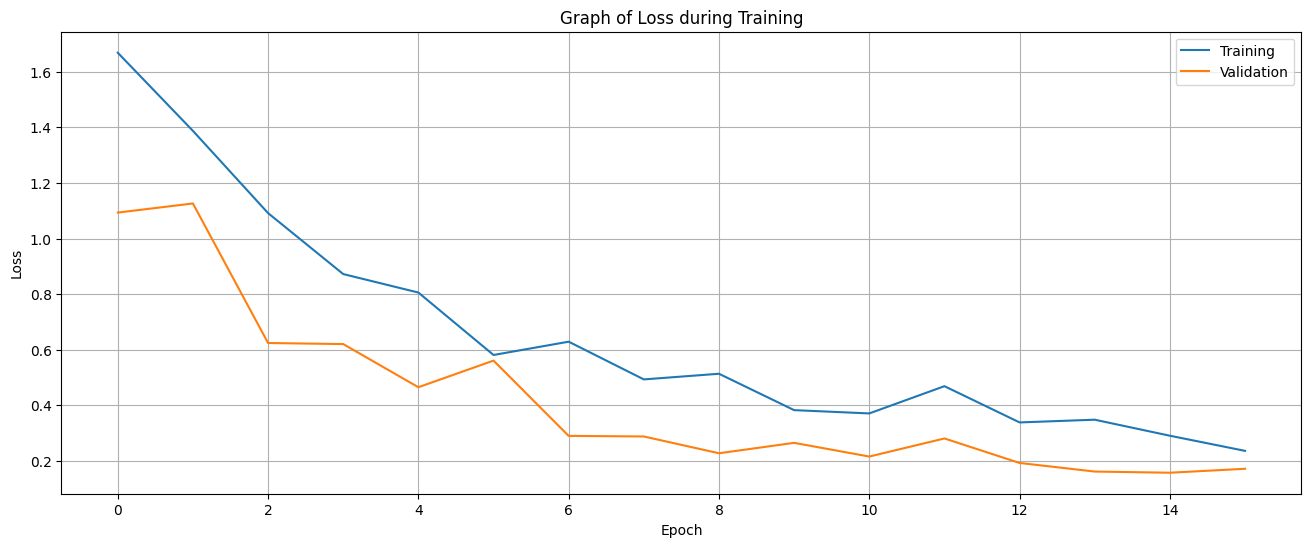

In [46]:
# Create the loss plot
plt.figure(figsize=(16, 6))
plt.plot(history_fine.history['loss'], label='Training')
plt.plot(history_fine.history['val_loss'], label='Validation')

# Customization of the plot
plt.title('Graph of Loss during Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc="upper right")
plt.grid(True)

# Print the plot
plt.savefig('loss_graph.png')